<div style="border-left:6px solid #ae0000; padding:6px 20px; margin-bottom:4px;">
<h1 style="margin:0; color:#0d2741;">Visualización de Datos con Seaborn</h1>
<p style="margin:4px 0 0 0; color:#0d2741; font-size:1.15em;">Histogramas, Boxplots y Gráficos de Barras</p>
<p style="margin:6px 0 0 0; color:#444; font-size:1.05em;"><em>Estadística Computacional para la Toma de Decisiones</em></p>
</div>

**Magíster en Ciencia de Datos e Inteligencia Artificial** · Universidad Andrés Bello  
Maidana, J.P. (2026)

---

> **Cómo usar este notebook.** Ejecuta las celdas en orden (de arriba hacia abajo). Comienza por la celda **«Preparación del entorno»**: importa las librerías y fija el tema visual que usarán todos los gráficos posteriores.

## Preparación del entorno

In [1]:
# Librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch   # solo para los diagramas explicativos

print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)
print("seaborn :", sns.__version__)

numpy   : 2.3.5
pandas  : 2.3.3
seaborn : 0.13.2


<div style="background-color:#fffceb; border-left:5px solid #f9a825; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#f57f17; font-size:1.05em;">📝&nbsp; Nota — Compatibilidad con versiones recientes de Seaborn</p>
<p style="margin:0;">A partir de <strong>Seaborn 0.14</strong>, pasar <code>palette=</code> sin una variable <code>hue</code> deja de estar permitido. En este notebook, cuando solo queremos colorear las barras/cajas por su propia categoría del eje X, usamos el patrón recomendado <code>hue='&lt;variable_x&gt;'</code> junto con <code>legend=False</code>. El resultado visual es idéntico al del apunte y el código funciona en Seaborn 0.12, 0.13 y 0.14+.</p>
</div>

## 1. Introducción: Comunicar Datos con Integridad Visual

Consideremos la siguiente situación: un equipo presenta los resultados de una campaña de marketing mediante una tabla de números. La tasa de conversión pasó de 2.1% a 2.3%. La audiencia no distingue si el cambio es relevante o trivial. Luego se construye un único gráfico con los mismos datos, mostrando la trayectoria temporal: una línea estable que sube claramente al activarse la campaña y se mantiene elevada. La interpretación es inmediata.

Mismos números, diferente historia. **La visualización comunicó lo que la tabla no pudo.**

El cerebro humano procesa imágenes con mucha mayor velocidad que texto o números en crudo. Patrones que requieren varios minutos de análisis en una tabla se detectan en segundos en un gráfico bien construido. Sin embargo, esta capacidad también puede explotarse de forma negativa: truncar ejes, usar perspectivas 3D que distorsionan proporciones, o seleccionar rangos que exageran diferencias menores son prácticas que, aunque técnicamente posibles, comprometen la integridad del análisis.

Por esta razón, este apunte no se limita a enseñar cómo producir gráficos con Seaborn. Su objetivo es desarrollar la capacidad de **comunicar verdad con claridad visual**.

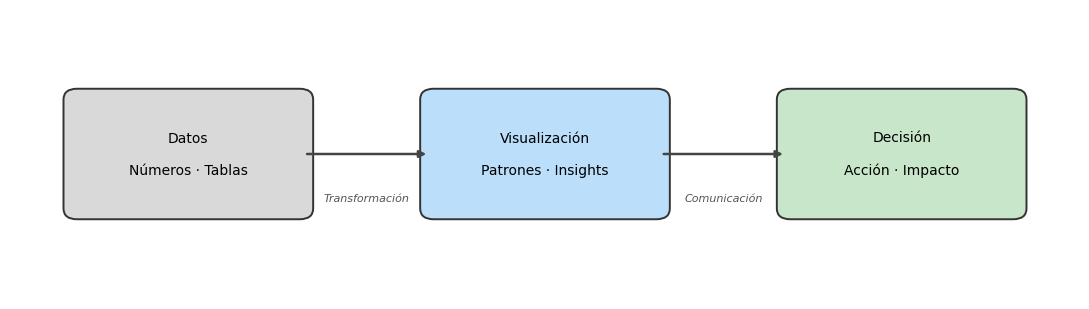

In [2]:
# Diagrama: del dato a la decisión
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 12); ax.set_ylim(0, 4); ax.axis('off')

def _box(x, txt, fc):
    ax.add_patch(FancyBboxPatch((x-1.3, 1.2), 2.6, 1.6,
        boxstyle="round,pad=0.1,rounding_size=0.15", fc=fc, ec='#333', lw=1.4))
    ax.text(x, 2.0, txt, ha='center', va='center', fontsize=10)

_box(2,  "Datos\n\nNúmeros · Tablas",          '#d9d9d9')
_box(6,  "Visualización\n\nPatrones · Insights", '#bbdefb')
_box(10, "Decisión\n\nAcción · Impacto",        '#c8e6c9')

for x1, x2, lbl in [(3.3, 4.7, 'Transformación'), (7.3, 8.7, 'Comunicación')]:
    ax.annotate('', xy=(x2, 2.0), xytext=(x1, 2.0),
        arrowprops=dict(arrowstyle='-|>', color='#444', lw=1.8))
    ax.text((x1+x2)/2, 1.35, lbl, ha='center', fontsize=8, style='italic', color='#555')

plt.tight_layout()
plt.show()

### 1.1 Por Qué Seaborn

Python cuenta con varias librerías de visualización. Seaborn se destaca porque combina facilidad de uso con rigor estadístico. Matplotlib, la base subyacente, ofrece control absoluto pero requiere código extenso para resultados básicos. Seaborn proporciona el 95% de lo necesario en pocas líneas.

**Características que distinguen a Seaborn:**

- **Integración nativa con pandas:** recibe DataFrames directamente, sin conversiones intermedias.
- **Estadísticos incorporados:** los intervalos de confianza en gráficos de barras se calculan automáticamente.
- **Estética profesional por defecto:** los gráficos se ven limpios sin configuración adicional.
- **Paletas accesibles:** colores diseñados para ser seguros ante daltonismo.
- **Manejo automático de categorías:** agrupación, coloración y etiquetado automatizados.
- **Sintaxis legible:** `sns.boxplot(data=df, x='grupo', y='valor')` es autoexplicativo.

<div style="background-color:#fffceb; border-left:5px solid #f9a825; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#f57f17; font-size:1.05em;">📝&nbsp; Nota — Lo que aprenderás en este apunte</p>
<ol style="margin:0;">
<li>Los tres gráficos más utilizados en análisis: histogramas, boxplots y barras.</li>
<li>Criterios para seleccionar el gráfico apropiado según el tipo de dato.</li>
<li>Implementación con Seaborn.</li>
<li>Principios de diseño visual que distinguen gráficos amateur de profesionales.</li>
<li>Interpretación de distribuciones, outliers y comparaciones.</li>
<li>Construcción de dashboards analíticos integrados.</li>
<li>Errores comunes a evitar.</li>
</ol>
</div>

## 2. El Ecosistema de Visualización en Python

Antes de escribir código, es útil entender el contexto de herramientas disponibles.

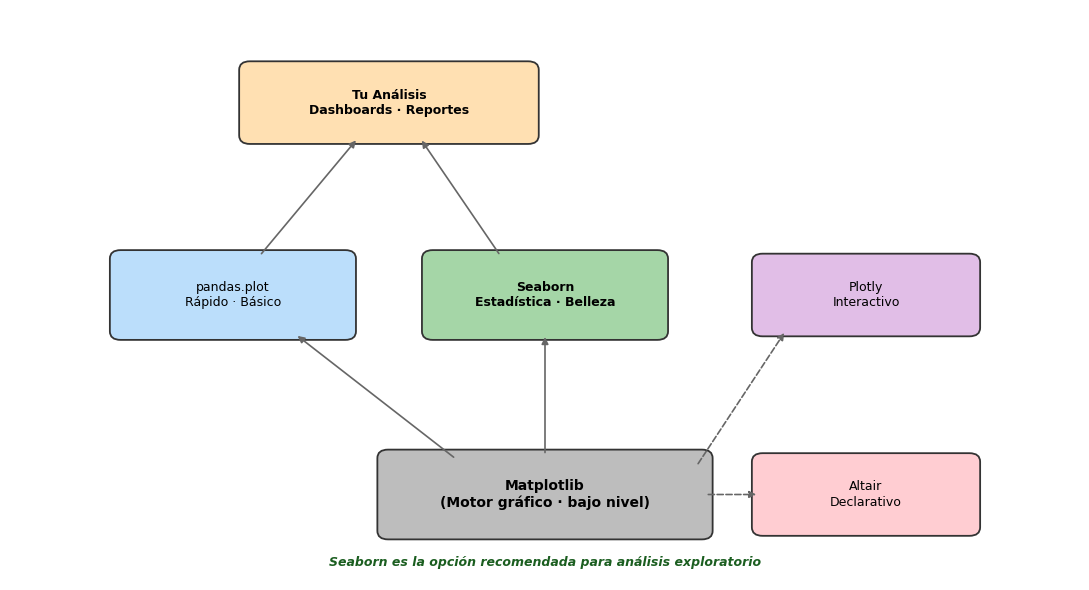

In [3]:
# Diagrama: ecosistema de visualización en Python
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 12); ax.set_ylim(0, 8); ax.axis('off')

def _box(x, y, w, h, txt, fc, fs=9, fw='normal'):
    ax.add_patch(FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle="round,pad=0.08,rounding_size=0.12", fc=fc, ec='#333', lw=1.3))
    ax.text(x, y, txt, ha='center', va='center', fontsize=fs, fontweight=fw)

def _arr(x1, y1, x2, y2, dashed=False):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='-|>', color='#666', lw=1.2,
                        linestyle='--' if dashed else '-'))

_box(6, 1.2, 3.6, 1.1, "Matplotlib\n(Motor gráfico · bajo nivel)", '#bdbdbd', 10, 'bold')
_box(2.5, 4, 2.6, 1.1, "pandas.plot\nRápido · Básico", '#bbdefb', 9)
_box(6, 4, 2.6, 1.1, "Seaborn\nEstadística · Belleza", '#a5d6a7', 9, 'bold')
_box(9.6, 4, 2.4, 1.0, "Plotly\nInteractivo", '#e1bee7', 9)
_box(9.6, 1.2, 2.4, 1.0, "Altair\nDeclarativo", '#ffcdd2', 9)
_box(4.25, 6.7, 3.2, 1.0, "Tu Análisis\nDashboards · Reportes", '#ffe0b2', 9, 'bold')

_arr(5.0, 1.7, 3.2, 3.45)      # mpl -> pandas
_arr(6, 1.75, 6, 3.45)         # mpl -> seaborn
_arr(2.8, 4.55, 3.9, 6.2)      # pandas -> apps
_arr(5.5, 4.55, 4.6, 6.2)      # seaborn -> apps
_arr(7.7, 1.6, 8.7, 3.5, dashed=True)   # mpl -> plotly
_arr(7.8, 1.2, 8.4, 1.2, dashed=True)   # mpl -> altair

ax.text(6, 0.2, "Seaborn es la opción recomendada para análisis exploratorio",
        ha='center', fontsize=9, style='italic', color='#1b5e20', fontweight='bold')
plt.tight_layout()
plt.show()

**Criterios de selección:**

- **Seaborn:** análisis exploratorio, reportes estadísticos (uso mayoritario).
- **Matplotlib puro:** control total, publicaciones científicas, gráficos altamente personalizados.
- **Plotly:** dashboards interactivos, visualizaciones web.
- **pandas.plot:** exploración rápida e informal durante el desarrollo.

## 3. Fundamentos: La Gramática de los Gráficos

Todo gráfico comparte los mismos componentes estructurales.

| Componente | Descripción |
|---|---|
| **Datos** | El DataFrame que se desea visualizar. |
| **Estética** | Cómo se mapean variables a atributos visuales: ¿qué va en X y en Y?, ¿qué variable define el color?, ¿tamaño?, ¿forma? |
| **Geometría** | El tipo de marca visual: barras, puntos, líneas, cajas, áreas. |
| **Escalas** | Cómo se convierten números en posiciones: lineal, log, categórica. |
| **Facetas** | División en mini-gráficos por categoría. |
| **Tema** | Colores, fuentes y estilo general. |

<div align="center"><em>Tabla 3.1 — Componentes estructurales de todo gráfico.</em></div>

### 3.1 Selección del Gráfico Apropiado

| Tipo de dato | Subtipo | Gráfico | Para observar |
|---|---|---|---|
| 1 variable continua | Numérica | Histograma | Forma, modas, asimetría |
| | | KDE | Densidad suavizada |
| | | Boxplot | Resumen estadístico + outliers |
| 1 variable categórica | Nominal | Barplot | Frecuencias |
| | | Countplot | Conteo directo |
| Continua + Categórica | Num. + Nominal | Boxplot | Comparación entre grupos |
| | | Violin | Distribución detallada |
| Dos categóricas | Nominal + Nominal | Barplot | Frecuencias cruzadas |
| | | Heatmap | Matriz completa |

<div align="center"><em>Tabla 3.2 — Guía de selección de gráficos según tipo de dato.</em></div>

## 4. Configuración del Entorno

La siguiente configuración establece un entorno estandarizado para todos los gráficos. Aplica el tema visual, la escala de fuentes y el tamaño de figura por defecto.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Si se trabaja en Jupyter
%matplotlib inline

# Configurar tema global
sns.set_theme(
    style="whitegrid",    # Fondo blanco + grilla (limpio, profesional)
    palette="deep",       # Paleta de colores
    font_scale=1.1        # Fuentes 10% más grandes para legibilidad
)

# Contexto (escala de elementos)
sns.set_context("notebook")  # Adecuado para Jupyter

# Tamaño y resolución de figuras
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Formato numérico
pd.options.display.float_format = '{:.2f}'.format

print("Entorno configurado correctamente")
print(f"Versión seaborn: {sns.__version__}")

Entorno configurado correctamente
Versión seaborn: 0.13.2


<div style="background-color:#fff4e6; border-left:5px solid #e65100; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#bf360c; font-size:1.05em;">⭐&nbsp; Importante — Estilos y Contextos de Seaborn</p>
<p style="margin:0 0 4px 0;"><strong>Estilos disponibles:</strong></p>
<ul style="margin:0 0 8px 0;">
<li><code>whitegrid</code>: fondo blanco + grilla gris → reportes y documentos ✔</li>
<li><code>darkgrid</code>: fondo gris + grilla blanca → presentaciones oscuras.</li>
<li><code>white</code>: minimalista sin grilla → publicaciones y journals.</li>
<li><code>dark</code>: fondo oscuro sin grilla → presentaciones de alto contraste.</li>
<li><code>ticks</code>: solo marcas en ejes → estilo clásico.</li>
</ul>
<p style="margin:0 0 4px 0;"><strong>Contextos:</strong></p>
<ul style="margin:0 0 8px 0;">
<li><code>paper</code>: escala pequeña → papers académicos.</li>
<li><code>notebook</code>: escala estándar → Jupyter, análisis diario ✔</li>
<li><code>talk</code>: escala grande → presentaciones en sala.</li>
<li><code>poster</code>: escala muy grande → pósters de conferencias.</li>
</ul>
<p style="margin:0;"><strong>Recomendación inicial:</strong> <code>whitegrid</code> + <code>notebook</code> es adecuado para la mayoría de contextos analíticos.</p>
</div>

## 5. Histogramas: Visualizar la Distribución

### 5.1 Cuándo y Por Qué

Un histograma responde preguntas que los estadísticos numéricos solos no pueden resolver con claridad:

- **¿Es simétrica o sesgada la distribución?** La media y mediana dan una pista, pero el histograma lo muestra directamente.
- **¿Hay múltiples modas?** Una distribución bimodal puede indicar dos subpoblaciones mezcladas.
- **¿Hay outliers?** Se identifican visualmente de inmediato.
- **¿Es aproximadamente normal?** Información relevante para decidir qué tests estadísticos son apropiados.

<div style="background-color:#e8f1fb; border-left:5px solid #1565c0; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#0d47a1; font-size:1.05em;">📘&nbsp; Definición — Histograma</p>
<p style="margin:0 0 8px 0;">Un <strong>histograma</strong> divide datos continuos en intervalos (<em>bins</em>) y cuenta las observaciones en cada uno.</p>
<p style="margin:0 0 4px 0;"><strong>Selección del número de bins:</strong></p>
<ul style="margin:0 0 8px 0;">
<li><strong>Pocos bins</strong> (5–10): pérdida de detalle, sobre-suavizado.</li>
<li><strong>Muchos bins</strong> (100+): ruido visible, picos espurios.</li>
<li><strong>Rango adecuado</strong> (20–50 típicamente): patrones reales visibles.</li>
</ul>
<p style="margin:0 0 4px 0;"><strong>Reglas formales:</strong></p>
<ul style="margin:0;">
<li><strong>Sturges:</strong> k = ⌈log₂(n) + 1⌉ (conservador).</li>
<li><strong>Rice:</strong> k = ⌈2·n^(1/3)⌉ (más bins).</li>
<li><strong>Freedman-Diaconis:</strong> basado en el IQR, robusto ante outliers ✔</li>
<li><strong>Regla práctica:</strong> comenzar con √n y ajustar visualmente.</li>
</ul>
</div>

### 5.2 Implementación

El siguiente ejemplo genera una distribución bimodal — situación que ocurre cuando dos grupos distintos se analizan de forma conjunta.

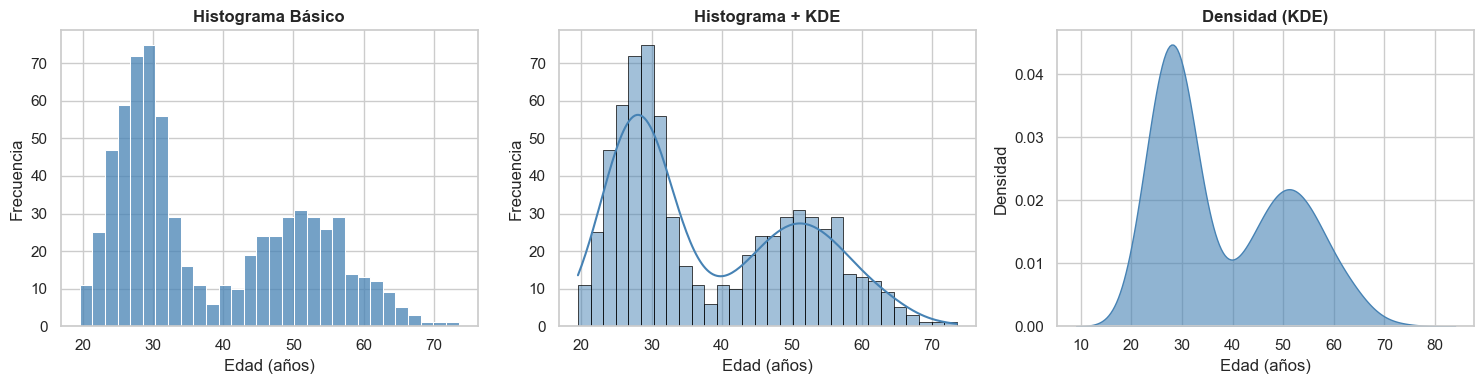

ANÁLISIS DE EDADES
Media:    38.3 años
Mediana:  32.3 años
Desv. Est.: 12.9 años
Asimetría: 0.520
Curtosis:  -1.087

Interpretación: distribución bimodal.
Existen dos segmentos diferenciados de clientes.


In [5]:
# Generar datos: dos segmentos de clientes
np.random.seed(42)

jovenes = np.random.normal(loc=28, scale=4, size=400)
maduros = np.random.normal(loc=52, scale=7, size=300)
edades = np.concatenate([jovenes, maduros])
edades = edades[(edades >= 18) & (edades <= 75)]

df_clientes = pd.DataFrame({'edad': edades})

# Tres representaciones de la misma distribución
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Histograma básico
sns.histplot(data=df_clientes, x='edad', bins=30,
             color='steelblue', ax=axes[0])
axes[0].set_title('Histograma Básico', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')

# 2. Histograma + KDE (curva de densidad suavizada)
sns.histplot(data=df_clientes, x='edad', bins=30, kde=True,
             color='steelblue', edgecolor='black',
             linewidth=0.5, ax=axes[1])
axes[1].set_title('Histograma + KDE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('Frecuencia')

# 3. Solo KDE
sns.kdeplot(data=df_clientes, x='edad', fill=True,
            color='steelblue', alpha=0.6, ax=axes[2])
axes[2].set_title('Densidad (KDE)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Edad (años)')
axes[2].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

# Estadísticos descriptivos
print("="*60)
print("ANÁLISIS DE EDADES")
print("="*60)
print(f"Media:    {df_clientes['edad'].mean():.1f} años")
print(f"Mediana:  {df_clientes['edad'].median():.1f} años")
print(f"Desv. Est.: {df_clientes['edad'].std():.1f} años")
print(f"Asimetría: {df_clientes['edad'].skew():.3f}")
print(f"Curtosis:  {df_clientes['edad'].kurt():.3f}")
print("\nInterpretación: distribución bimodal.")
print("Existen dos segmentos diferenciados de clientes.")

El patrón bimodal tiene una implicación analítica importante: el promedio (aproximadamente 38 años en este caso) **no representa a ninguno de los dos grupos**. Calcular estadísticos sobre toda la muestra sin considerar esta heterogeneidad puede conducir a conclusiones incorrectas.

### 5.3 Comparación entre Grupos

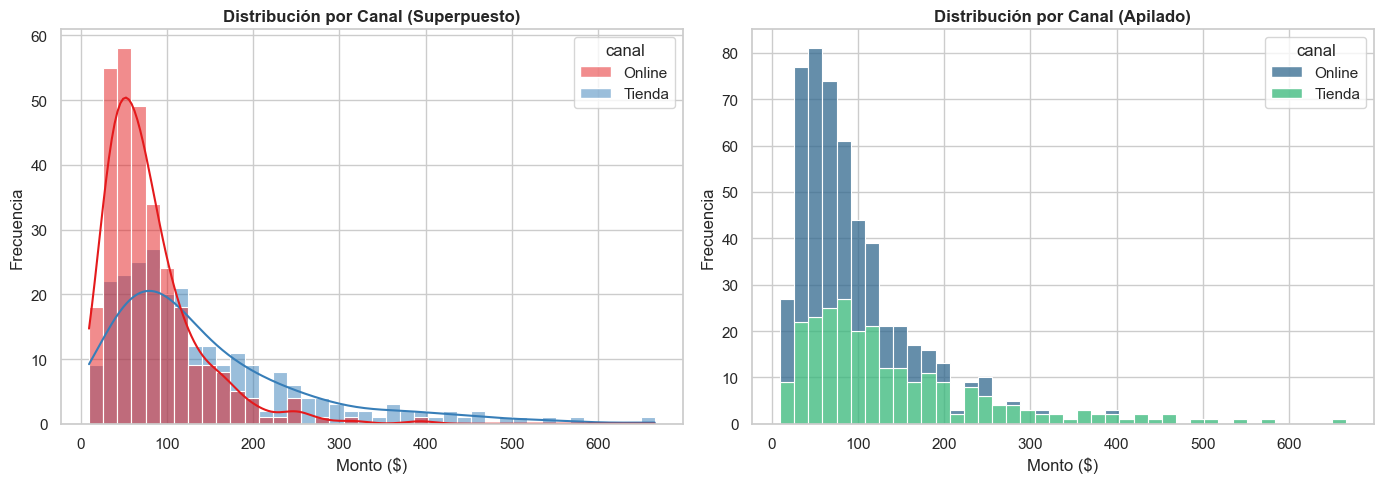


COMPARACIÓN ONLINE VS TIENDA:
        count   mean    std   min   25%    50%    75%    max
canal                                                       
Online 300.00  79.26  53.57  9.60 42.95  65.96  99.46 393.54
Tienda 250.00 142.27 113.94 11.82 64.87 107.31 187.21 665.50


In [6]:
# Montos de compra por canal
np.random.seed(123)
df_ventas = pd.DataFrame({
    'monto': np.concatenate([
        np.random.lognormal(4.2, 0.6, 300),
        np.random.lognormal(4.7, 0.8, 250)
    ]),
    'canal': ['Online']*300 + ['Tienda']*250
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Superpuesto con transparencia
sns.histplot(data=df_ventas, x='monto', hue='canal',
             bins=40, kde=True, alpha=0.5,
             palette='Set1', ax=axes[0])
axes[0].set_title('Distribución por Canal (Superpuesto)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Monto ($)')
axes[0].set_ylabel('Frecuencia')

# Apilado
sns.histplot(data=df_ventas, x='monto', hue='canal',
             bins=40, multiple='stack',
             palette='viridis', ax=axes[1])
axes[1].set_title('Distribución por Canal (Apilado)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monto ($)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("\nCOMPARACIÓN ONLINE VS TIENDA:")
print(df_ventas.groupby('canal')['monto'].describe().round(2))

<div style="background-color:#e9f7ea; border-left:5px solid #2e7d32; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#1b5e20; font-size:1.05em;">✅&nbsp; Ejemplo — Aplicaciones de Histogramas en Distintas Industrias</p>
<p style="margin:0 0 6px 0;"><strong>Finanzas:</strong> retornos diarios de portafolios. La presencia de colas más pesadas que la normal indica que los modelos que asumen normalidad pueden subestimar el riesgo real.</p>
<p style="margin:0 0 6px 0;"><strong>Control de Calidad:</strong> tiempos de producción con distribución bimodal pueden indicar diferencias entre turnos u operarios que ameritan investigación.</p>
<p style="margin:0 0 6px 0;"><strong>Marketing:</strong> segmentación por edad. Un patrón bimodal claro (por ejemplo, millennials y boomers) sugiere que estrategias genéricas son poco eficientes.</p>
<p style="margin:0;"><strong>Salud:</strong> distribución asimétrica positiva de IMC indica concentración de casos en el extremo superior, lo que puede orientar decisiones de programas de intervención.</p>
</div>

**⭐ Parámetros clave de `sns.histplot()`**

```python
sns.histplot(
    data=df,
    x='variable',
    bins=30,              # Número de bins
    kde=True,             # Agregar curva de densidad
    stat='count',         # 'count', 'frequency', 'density', 'probability'
    hue='categoria',      # Variable para colorear grupos
    multiple='layer',     # 'layer', 'dodge', 'stack', 'fill'
    alpha=0.7,            # Transparencia
    color='steelblue',
    palette='Set2',
    edgecolor='black',
    linewidth=0.5
)
```

**Configuración sugerida:** `bins=30–40`, `kde=True`, `alpha=0.7` al comparar grupos.

## 6. Boxplots: El Resumen de Cinco Números

### 6.1 Ventajas del Boxplot

Los boxplots son altamente eficientes en el uso del espacio: en una figura compacta transmiten cinco estadísticos simultáneamente: mediana, cuartiles Q₁ y Q₃, valores extremos típicos y outliers. Además, al basarse en la mediana en lugar de la media, son robustos ante valores atípicos.

<div style="background-color:#e8f1fb; border-left:5px solid #1565c0; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#0d47a1; font-size:1.05em;">📘&nbsp; Definición — Boxplot</p>
<p style="margin:0 0 6px 0;">Un <strong>boxplot</strong> resume una distribución mediante cinco estadísticos:</p>
<ol style="margin:0 0 8px 0;">
<li><strong>Caja:</strong> del percentil 25 (Q₁) al 75 (Q₃). Altura = IQR = Q₃ − Q₁. Contiene el 50% central de los datos.</li>
<li><strong>Línea central:</strong> mediana (Q₂, percentil 50).</li>
<li><strong>Bigote inferior:</strong> hasta Q₁ − 1.5 × IQR.</li>
<li><strong>Bigote superior:</strong> hasta Q₃ + 1.5 × IQR.</li>
<li><strong>Outliers:</strong> puntos individuales más allá de los bigotes (regla de Tukey).</li>
</ol>
<p style="margin:0;"><strong>Regla de Tukey para identificar outliers:</strong> x es outlier si x &lt; Q₁ − 1.5 × IQR &nbsp; o &nbsp; x &gt; Q₃ + 1.5 × IQR.</p>
</div>

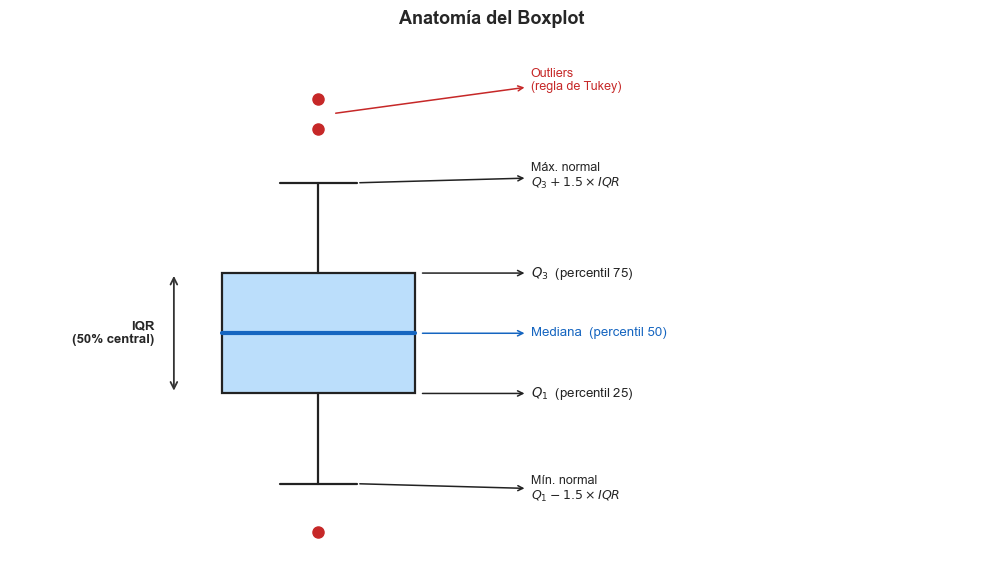

In [7]:
# Diagrama: anatomía del boxplot
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 9); ax.axis('off')
cx = 3.2

# Caja, mediana, bigotes y tapas
ax.add_patch(plt.Rectangle((cx-1, 3), 2, 2, fill=True, fc='#bbdefb', ec='#222', lw=1.6))
ax.plot([cx-1, cx+1], [4, 4], color='#1565c0', lw=3)          # mediana
ax.plot([cx, cx], [5, 6.5], color='#222', lw=1.6)             # bigote superior
ax.plot([cx, cx], [3, 1.5], color='#222', lw=1.6)             # bigote inferior
ax.plot([cx-0.4, cx+0.4], [6.5, 6.5], color='#222', lw=1.6)   # tapa superior
ax.plot([cx-0.4, cx+0.4], [1.5, 1.5], color='#222', lw=1.6)   # tapa inferior

# Outliers
for yy in [7.4, 7.9, 0.7]:
    ax.plot(cx, yy, 'o', color='#c62828', ms=8)

# Etiquetas
def _lab(y, txt, color='#222'):
    ax.annotate(txt, xy=(cx+1.05, y), xytext=(5.4, y), fontsize=9.5, color=color,
                va='center', arrowprops=dict(arrowstyle='<-', color=color, lw=1.1))
_lab(5, "$Q_3$  (percentil 75)")
_lab(4, "Mediana  (percentil 50)", '#1565c0')
_lab(3, "$Q_1$  (percentil 25)")
ax.annotate("Máx. normal\n$Q_3 + 1.5\\times IQR$", xy=(cx+0.4, 6.5), xytext=(5.4, 6.6),
            fontsize=9, va='center', arrowprops=dict(arrowstyle='<-', color='#222', lw=1.1))
ax.annotate("Mín. normal\n$Q_1 - 1.5\\times IQR$", xy=(cx+0.4, 1.5), xytext=(5.4, 1.4),
            fontsize=9, va='center', arrowprops=dict(arrowstyle='<-', color='#222', lw=1.1))
ax.annotate("Outliers\n(regla de Tukey)", xy=(cx+0.15, 7.65), xytext=(5.4, 8.2),
            fontsize=9, color='#c62828', va='center',
            arrowprops=dict(arrowstyle='<-', color='#c62828', lw=1.1))

# Llave IQR
ax.annotate('', xy=(cx-1.5, 3), xytext=(cx-1.5, 5),
            arrowprops=dict(arrowstyle='<->', color='#333', lw=1.3))
ax.text(cx-1.7, 4, "IQR\n(50% central)", ha='right', va='center', fontsize=9.5, fontweight='bold')

ax.set_title("Anatomía del Boxplot", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Ventajas para comparaciones:**

- Permiten colocar 10–20 grupos en una misma figura de forma legible.
- La mediana no se distorsiona por outliers extremos.
- Los outliers son explícitamente visibles.
- La comparación de medianas, dispersión y simetría es directa.

### 6.2 Implementación

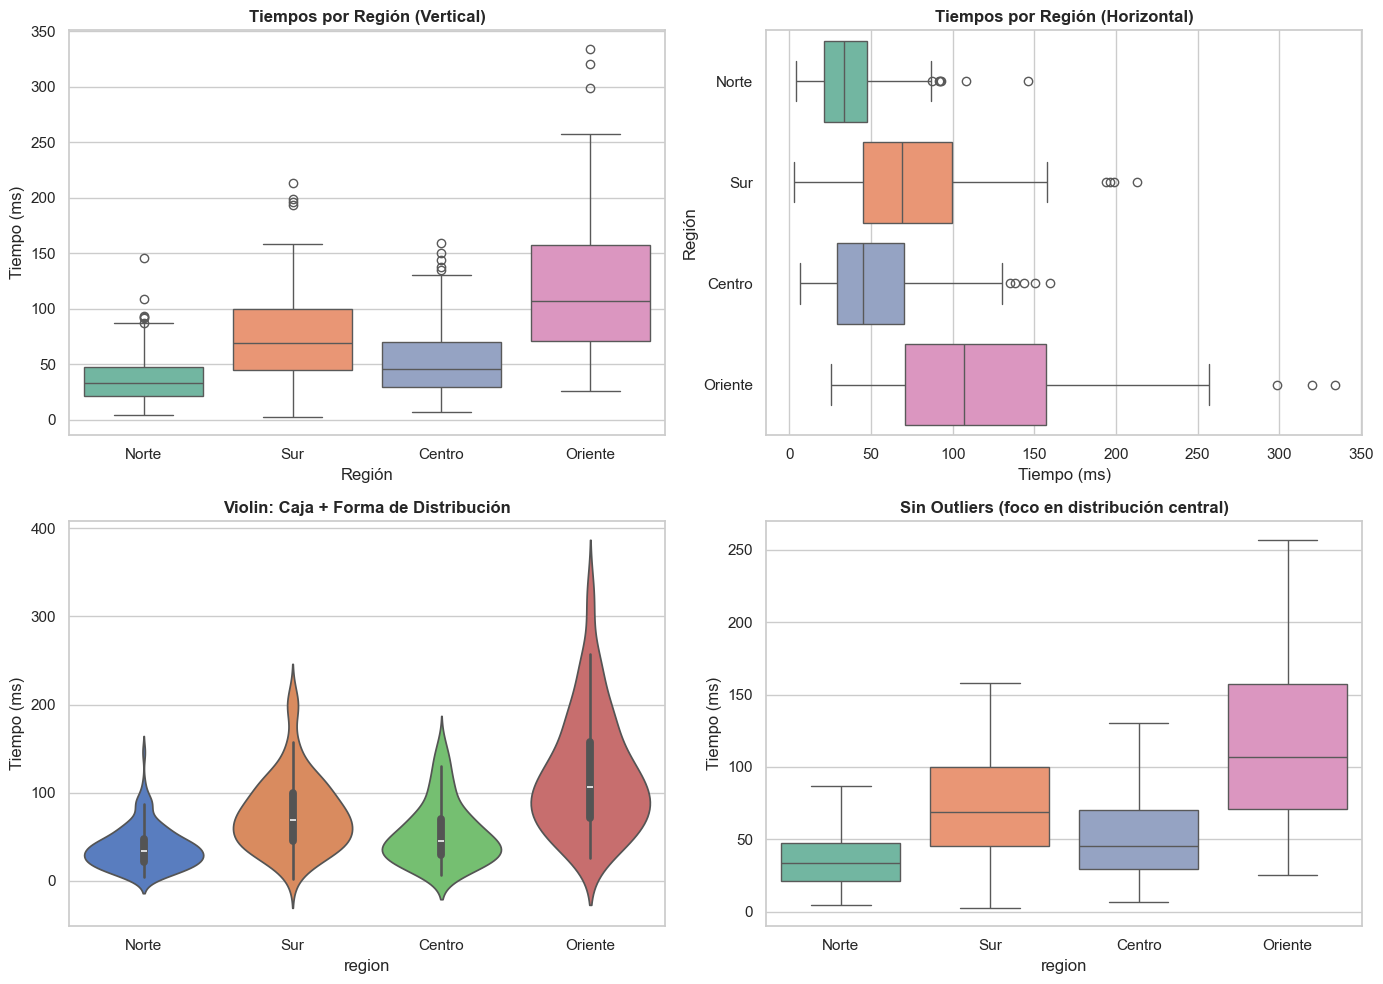

ANÁLISIS DE PERFORMANCE POR REGIÓN
           N  Media  Mediana    Q1     Q3   IQR  Desv.Est  Outliers
region                                                             
Centro   110  54.12    45.25 29.33  70.34 41.01     35.18         5
Norte    120  37.92    33.33 21.06  47.52 26.47     23.81         6
Oriente  103 120.87   106.91 71.08 157.03 85.95     66.73         3
Sur      100  76.64    68.81 45.12  99.72 54.59     41.70         4

Oriente requiere revisión: mediana elevada y outliers presentes.


In [8]:
# Tiempos de respuesta de servidores por región
np.random.seed(42)
regiones = ['Norte', 'Sur', 'Centro', 'Oriente']
datos = []

for region in regiones:
    if region == 'Norte':
        tiempos = np.random.gamma(2, 20, 120)
    elif region == 'Sur':
        tiempos = np.random.gamma(3, 25, 100)
    elif region == 'Centro':
        tiempos = np.random.gamma(2.5, 22, 110)
    else:  # Oriente - con problemas de latencia
        tiempos = np.random.gamma(4, 30, 100)
        tiempos = np.concatenate([tiempos, [200, 250, 320]])
    for t in tiempos:
        datos.append({'region': region, 'tiempo_ms': t})

df_servidores = pd.DataFrame(datos)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot vertical
sns.boxplot(data=df_servidores, x='region', y='tiempo_ms',
            hue='region', palette='Set2', legend=False, ax=axes[0,0])
axes[0,0].set_title('Tiempos por Región (Vertical)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Tiempo (ms)'); axes[0,0].set_xlabel('Región')

# Boxplot horizontal
sns.boxplot(data=df_servidores, y='region', x='tiempo_ms',
            hue='region', palette='Set2', legend=False, orient='h', ax=axes[0,1])
axes[0,1].set_title('Tiempos por Región (Horizontal)', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Tiempo (ms)'); axes[0,1].set_ylabel('Región')

# Violin plot
sns.violinplot(data=df_servidores, x='region', y='tiempo_ms',
               hue='region', palette='muted', legend=False, ax=axes[1,0])
axes[1,0].set_title('Violin: Caja + Forma de Distribución', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Tiempo (ms)')

# Sin outliers
sns.boxplot(data=df_servidores, x='region', y='tiempo_ms',
            hue='region', palette='Set2', legend=False, showfliers=False, ax=axes[1,1])
axes[1,1].set_title('Sin Outliers (foco en distribución central)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Tiempo (ms)')

plt.tight_layout()
plt.show()

# Estadísticos por región
print("ANÁLISIS DE PERFORMANCE POR REGIÓN")
print("="*70)
stats_region = df_servidores.groupby('region')['tiempo_ms'].agg([
    ('N', 'count'),
    ('Media', 'mean'),
    ('Mediana', 'median'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75)),
    ('IQR', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    ('Desv.Est', 'std'),
    ('Outliers', lambda x: (
        (x < x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25))) |
        (x > x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25)))
    ).sum())
])
print(stats_region.round(2))
print("\nOriente requiere revisión: mediana elevada y outliers presentes.")

El gráfico permite identificar de inmediato que Norte y Centro presentan cajas compactas y medianas bajas (alta consistencia y velocidad), mientras que Oriente muestra mediana alta con puntos fuera de los bigotes, indicando problemas de latencia intermitente que justifican investigación.

### 6.3 Boxplots Agrupados

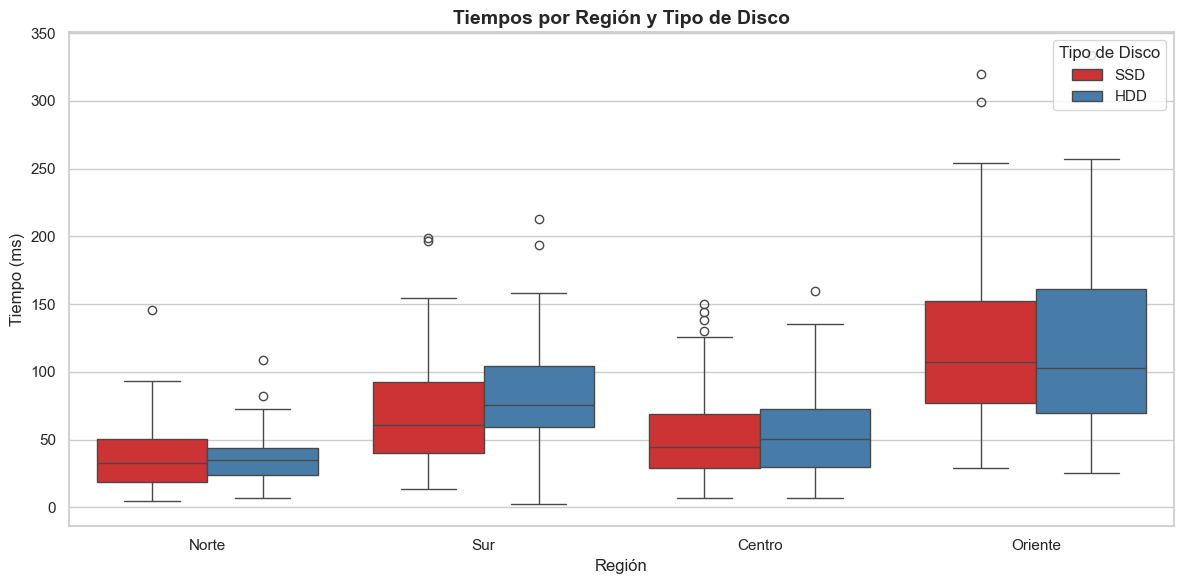


MEDIANA POR REGIÓN Y TIPO DE DISCO:
tipo_disco    HDD    SSD
region                  
Centro      50.09  44.20
Norte       35.14  32.99
Oriente    102.93 107.52
Sur         75.41  60.59


In [9]:
# Agregar variable de tipo de disco
df_servidores['tipo_disco'] = np.random.choice(
    ['SSD', 'HDD'], len(df_servidores), p=[0.6, 0.4]
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_servidores, x='region', y='tiempo_ms',
            hue='tipo_disco', palette='Set1')
plt.title('Tiempos por Región y Tipo de Disco', fontsize=14, fontweight='bold')
plt.ylabel('Tiempo (ms)', fontsize=12)
plt.xlabel('Región', fontsize=12)
plt.legend(title='Tipo de Disco', loc='upper right')
plt.tight_layout()
plt.show()

print("\nMEDIANA POR REGIÓN Y TIPO DE DISCO:")
pivot = df_servidores.pivot_table(
    values='tiempo_ms', index='region',
    columns='tipo_disco', aggfunc='median'
)
print(pivot.round(2))

<div style="background-color:#e9f7ea; border-left:5px solid #2e7d32; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#1b5e20; font-size:1.05em;">✅&nbsp; Ejemplo — Aplicaciones de Boxplots en Distintos Contextos</p>
<p style="margin:0 0 6px 0;"><strong>A/B Testing:</strong> comparar distribuciones de conversión entre versiones. La mediana indica el comportamiento central, mientras que los outliers pueden revelar segmentos de usuarios con engagement muy alto.</p>
<p style="margin:0 0 6px 0;"><strong>Control de Calidad:</strong> peso de productos por turno. Una mediana más alta en un turno específico señala desviación del proceso que requiere intervención.</p>
<p style="margin:0 0 6px 0;"><strong>Análisis de Equidad Salarial:</strong> salarios por departamento y categoría. Los boxplots revelan brechas medianas y permiten identificar casos específicos de forma contextualizada.</p>
<p style="margin:0;"><strong>Operaciones de Salud:</strong> tiempos de espera por día de la semana. Mayor dispersión y outliers en fines de semana indica necesidad de ajuste en la dotación de personal.</p>
</div>

**⭐ Parámetros de `sns.boxplot()`**

```python
sns.boxplot(
    data=df,
    x='categoria',
    y='valor',
    hue='grupo',
    orient='v',        # 'v' vertical, 'h' horizontal
    palette='Set2',
    showfliers=True,   # Mostrar/ocultar outliers
    width=0.8,
    whis=1.5           # Factor de bigotes (1.5 = regla de Tukey)
)
```

> **Nota:** con más de 10 categorías, se recomienda orientación horizontal (`orient='h'`) para evitar superposición de etiquetas. Si coloreas por la misma variable del eje, usa `hue='categoria', legend=False`.

## 7. Gráficos de Barras: Para Variables Categóricas

### 7.1 Cuándo Corresponde Usar Barras

Los gráficos de barras están diseñados para variables categóricas. Sus usos principales son comparar magnitudes entre categorías, mostrar conteos o frecuencias, presentar rankings y visualizar proporciones.

<div style="background-color:#e8f1fb; border-left:5px solid #1565c0; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#0d47a1; font-size:1.05em;">📘&nbsp; Definición — Barras vs Histograma: la distinción fundamental</p>
<ul style="margin:0 0 8px 0;">
<li><strong>Gráfico de barras:</strong> categorías discretas (puede haber espacio entre barras). Ejemplo: ventas por producto. El orden puede ser arbitrario o por magnitud.</li>
<li><strong>Histograma:</strong> datos continuos (bins contiguos, sin espacios). Ejemplo: distribución de edades. El orden siempre es numérico.</li>
</ul>
<p style="margin:0 0 4px 0;"><strong>Tipos principales de barras:</strong></p>
<ul style="margin:0;">
<li><strong>Simples:</strong> una categoría, un valor agregado.</li>
<li><strong>Agrupadas:</strong> múltiples series comparadas lado a lado.</li>
<li><strong>Apiladas:</strong> series acumuladas verticalmente.</li>
<li><strong>Horizontales:</strong> preferibles cuando los nombres son largos o hay muchas categorías.</li>
</ul>
</div>

<div style="background-color:#fdecea; border-left:5px solid #c62828; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#b71c1c; font-size:1.05em;">⚠️&nbsp; Advertencia — Regla fundamental de los gráficos de barras</p>
<p style="margin:0 0 6px 0;">El eje Y debe comenzar <strong>siempre en cero</strong>. Truncarlo distorsiona la percepción visual y puede hacer que diferencias pequeñas parezcan sustanciales.</p>
<p style="margin:0;">Ejemplo concreto: si los valores reales son A=100 y B=110 (10% de diferencia), un eje que va de 95 a 115 hace que la barra de B parezca visualmente tres veces más alta que la de A. Eso es engañoso, independientemente de si se hace de forma intencional o no.</p>
</div>

### 7.2 Gráficos de Conteo

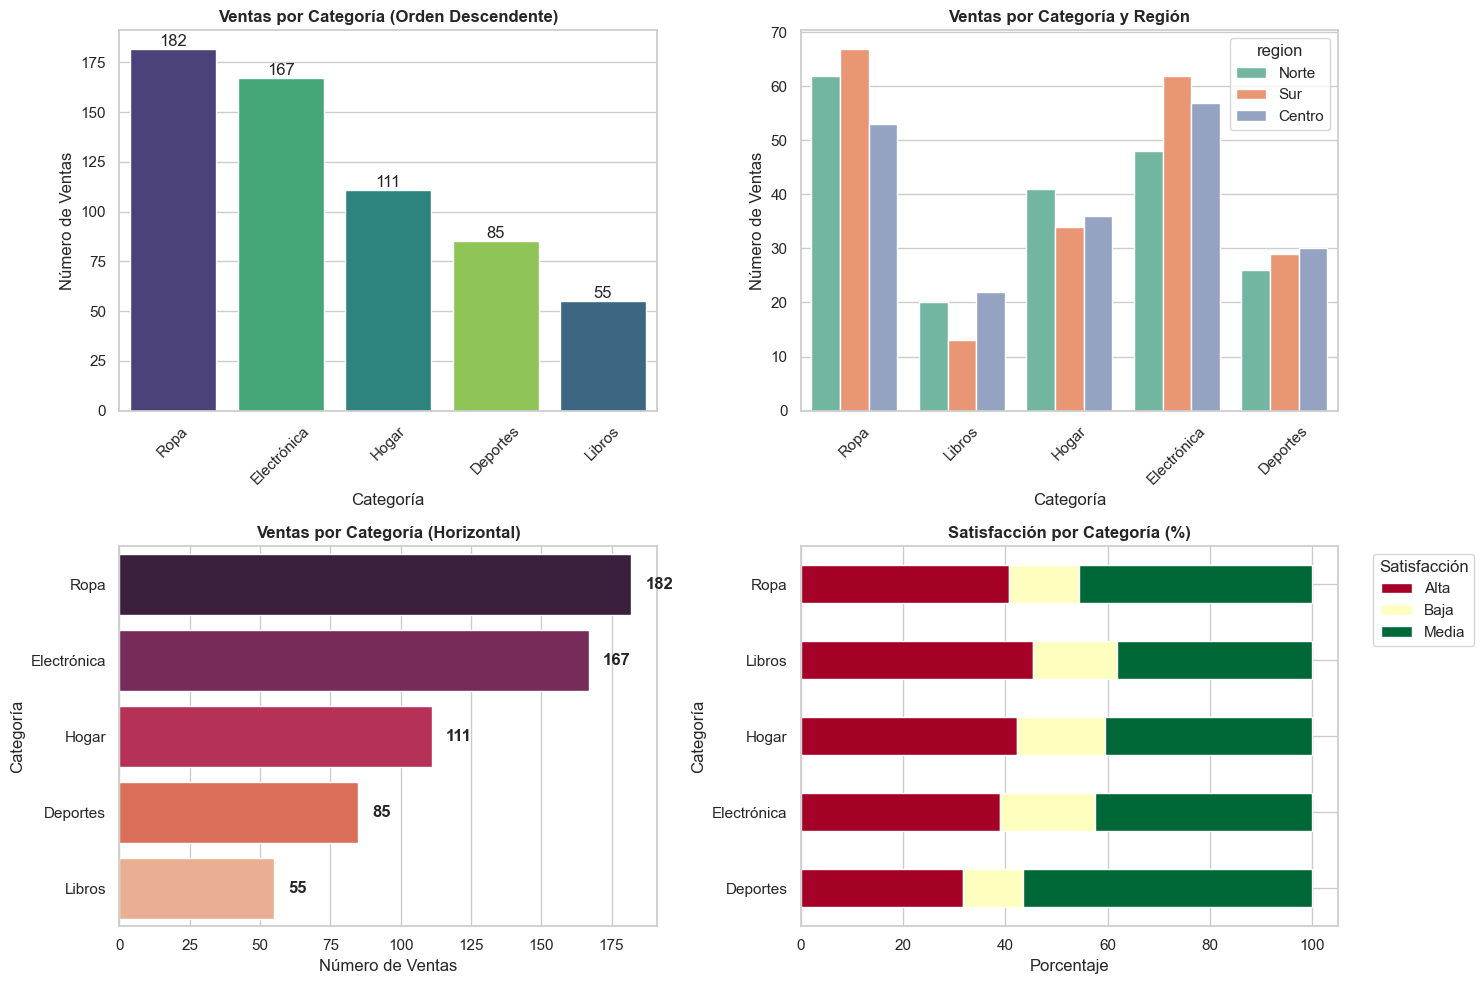

In [10]:
# Dataset de ventas por categoría
np.random.seed(42)
categorias = ['Electrónica', 'Ropa', 'Hogar', 'Deportes', 'Libros']
prob = [0.28, 0.32, 0.18, 0.14, 0.08]

df_productos = pd.DataFrame({
    'categoria': np.random.choice(categorias, size=600, p=prob),
    'region': np.random.choice(['Norte', 'Sur', 'Centro'], size=600),
    'satisfaccion': np.random.choice(['Baja', 'Media', 'Alta'],
                                     size=600, p=[0.15, 0.45, 0.40])
})

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Countplot ordenado por frecuencia (más informativo que orden alfabético)
orden = df_productos['categoria'].value_counts().index
sns.countplot(data=df_productos, x='categoria', hue='categoria',
              palette='viridis', order=orden, legend=False, ax=axes[0,0])
axes[0,0].set_title('Ventas por Categoría (Orden Descendente)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Categoría'); axes[0,0].set_ylabel('Número de Ventas')
axes[0,0].tick_params(axis='x', rotation=45)
for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt='%d')

# Comparación por región
sns.countplot(data=df_productos, x='categoria', hue='region',
              palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Ventas por Categoría y Región', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Categoría'); axes[0,1].set_ylabel('Número de Ventas')
axes[0,1].tick_params(axis='x', rotation=45)

# Horizontal
cat_counts = df_productos['categoria'].value_counts()
sns.barplot(y=cat_counts.index, x=cat_counts.values, hue=cat_counts.index,
            palette='rocket', orient='h', legend=False, ax=axes[1,0])
axes[1,0].set_title('Ventas por Categoría (Horizontal)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Número de Ventas'); axes[1,0].set_ylabel('Categoría')
for i, v in enumerate(cat_counts.values):
    axes[1,0].text(v + 5, i, str(v), va='center', fontweight='bold')

# Stacked 100% — distribución de satisfacción
sat_cross = pd.crosstab(df_productos['categoria'],
                        df_productos['satisfaccion'],
                        normalize='index') * 100
sat_cross.plot(kind='barh', stacked=True, colormap='RdYlGn', ax=axes[1,1])
axes[1,1].set_title('Satisfacción por Categoría (%)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Porcentaje'); axes[1,1].set_ylabel('Categoría')
axes[1,1].legend(title='Satisfacción', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

### 7.3 Barplot con Estadísticos Agregados

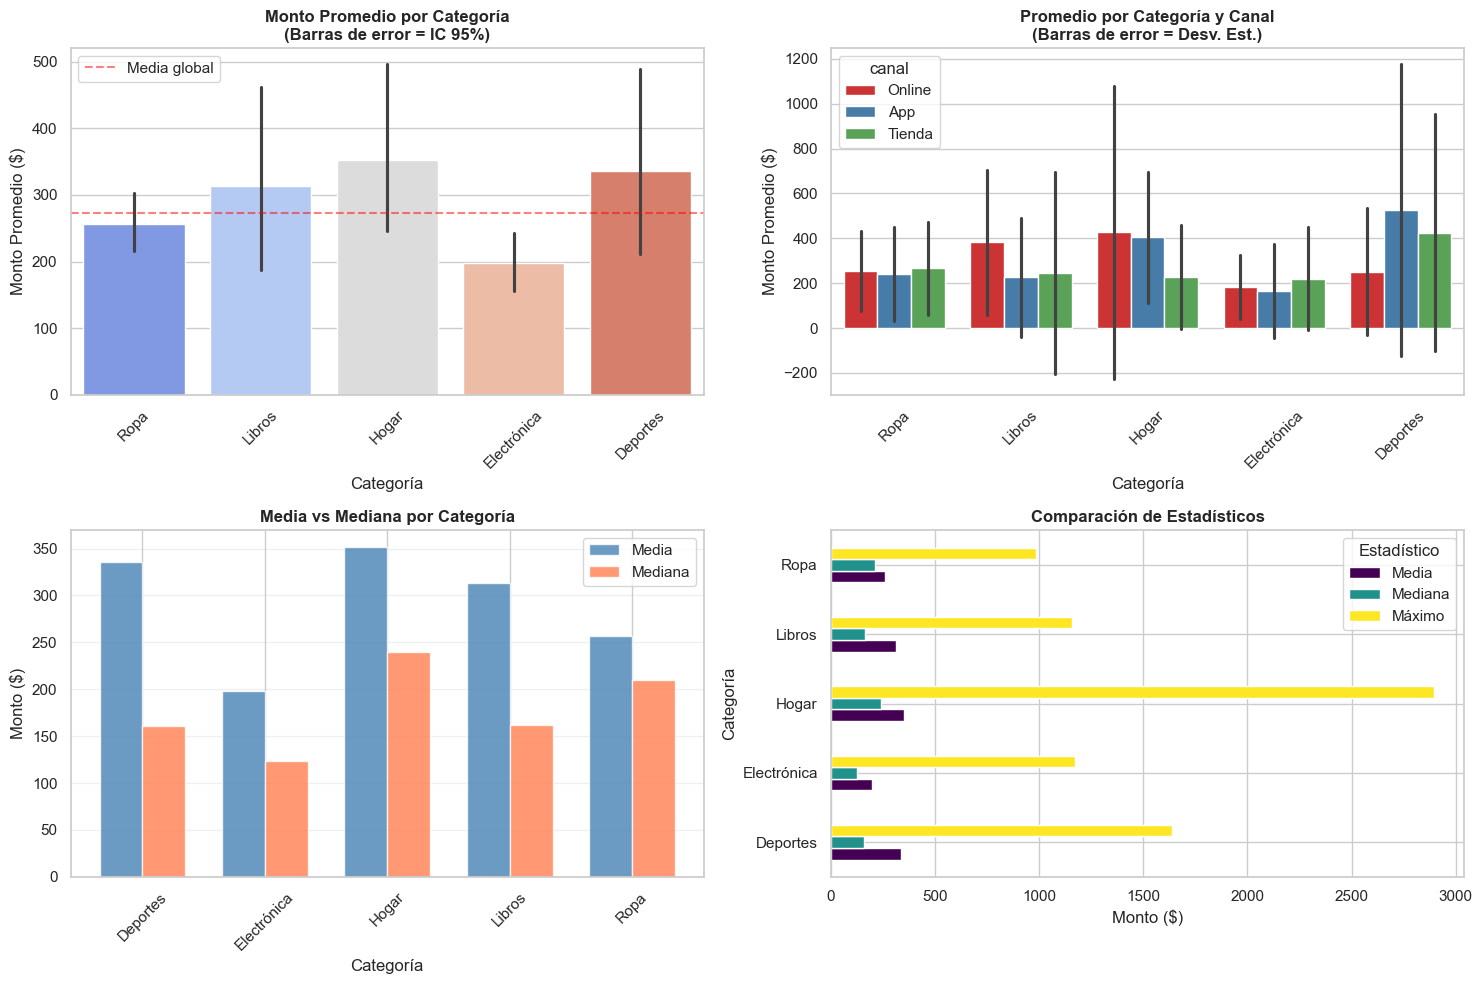


ESTADÍSTICOS POR CATEGORÍA
              N  Media  Mediana  Desv.Est   Min     Max    CV%
categoria                                                     
Deportes     34 335.89   160.54    419.71 37.23 1637.91 124.95
Electrónica  76 198.04   123.46    194.85 19.60 1173.63  98.39
Hogar        47 352.01   239.88    445.47 28.92 2895.73 126.55
Libros       21 312.90   161.87    345.39 33.66 1158.26 110.39
Ropa         72 257.08   209.85    190.48 22.83  986.16  74.09


In [11]:
# Dataset con valores numéricos por categoría
np.random.seed(42)
df_ventas = pd.DataFrame({
    'categoria': np.random.choice(categorias, size=250, p=prob),
    'canal': np.random.choice(['Online', 'Tienda', 'App'],
                              size=250, p=[0.50, 0.35, 0.15]),
    'monto': np.random.lognormal(5.2, 0.9, size=250)
})

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Promedio con intervalo de confianza 95%
sns.barplot(data=df_ventas, x='categoria', y='monto', hue='categoria',
            palette='coolwarm', errorbar='ci', legend=False, ax=axes[0,0])
axes[0,0].set_title('Monto Promedio por Categoría\n(Barras de error = IC 95%)',
                    fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Categoría'); axes[0,0].set_ylabel('Monto Promedio ($)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(df_ventas['monto'].mean(), color='red',
                  linestyle='--', alpha=0.5, label='Media global')
axes[0,0].legend()

# 2. Agrupado por canal con desviación estándar
sns.barplot(data=df_ventas, x='categoria', y='monto',
            hue='canal', palette='Set1', errorbar='sd', ax=axes[0,1])
axes[0,1].set_title('Promedio por Categoría y Canal\n(Barras de error = Desv. Est.)',
                    fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Categoría'); axes[0,1].set_ylabel('Monto Promedio ($)')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Comparación media vs mediana
stats_cat = df_ventas.groupby('categoria')['monto'].agg(['mean', 'median']).round(2)
x_pos = np.arange(len(stats_cat.index))
width = 0.35
axes[1,0].bar(x_pos - width/2, stats_cat['mean'], width,
              label='Media', color='steelblue', alpha=0.8)
axes[1,0].bar(x_pos + width/2, stats_cat['median'], width,
              label='Mediana', color='coral', alpha=0.8)
axes[1,0].set_title('Media vs Mediana por Categoría', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Categoría'); axes[1,0].set_ylabel('Monto ($)')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(stats_cat.index, rotation=45)
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# 4. Comparación de estadísticos
resultados = []
for cat in categorias:
    subset = df_ventas[df_ventas['categoria'] == cat]['monto']
    resultados.extend([
        {'Categoría': cat, 'Estadístico': 'Media', 'Valor': subset.mean()},
        {'Categoría': cat, 'Estadístico': 'Mediana', 'Valor': subset.median()},
        {'Categoría': cat, 'Estadístico': 'Máximo', 'Valor': subset.max()},
    ])
df_est = pd.DataFrame(resultados)
df_pivot = df_est.pivot(index='Categoría', columns='Estadístico', values='Valor')
df_pivot.plot(kind='barh', ax=axes[1,1], colormap='viridis')
axes[1,1].set_title('Comparación de Estadísticos', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Monto ($)')

plt.tight_layout()
plt.show()

print("\nESTADÍSTICOS POR CATEGORÍA")
print("="*70)
stats = df_ventas.groupby('categoria')['monto'].agg([
    ('N', 'count'), ('Media', 'mean'), ('Mediana', 'median'),
    ('Desv.Est', 'std'), ('Min', 'min'), ('Max', 'max'),
    ('CV%', lambda x: (x.std() / x.mean()) * 100)
])
print(stats.round(2))

El gráfico de media vs mediana es especialmente relevante: una diferencia significativa entre ambas indica asimetría o presencia de outliers. En datos de montos o ingresos, la mediana suele ser más representativa del caso típico.

**⭐ Parámetros de `countplot` y `barplot`**

```python
# countplot (solo cuenta observaciones)
sns.countplot(data=df, x='categoria', hue='grupo',
              order=['A','B'], palette='viridis')

# barplot (con agregación estadística)
sns.barplot(data=df, x='categoria', y='valor',
            hue='grupo',
            estimator='mean',   # 'mean', 'median', 'sum', función custom
            errorbar='ci',      # 'ci' (IC 95%), 'sd', None
            orient='v',
            palette='Set1')
```

**Comportamiento por defecto:** `barplot` muestra la media con IC 95%. Para usar la mediana, especificar `estimator='median'`.

## 8. Dashboard Analítico Integrado

El siguiente código construye un dashboard que integra los tres tipos de gráficos estudiados. Genera además un archivo `dashboard_ventas.png` en alta resolución.

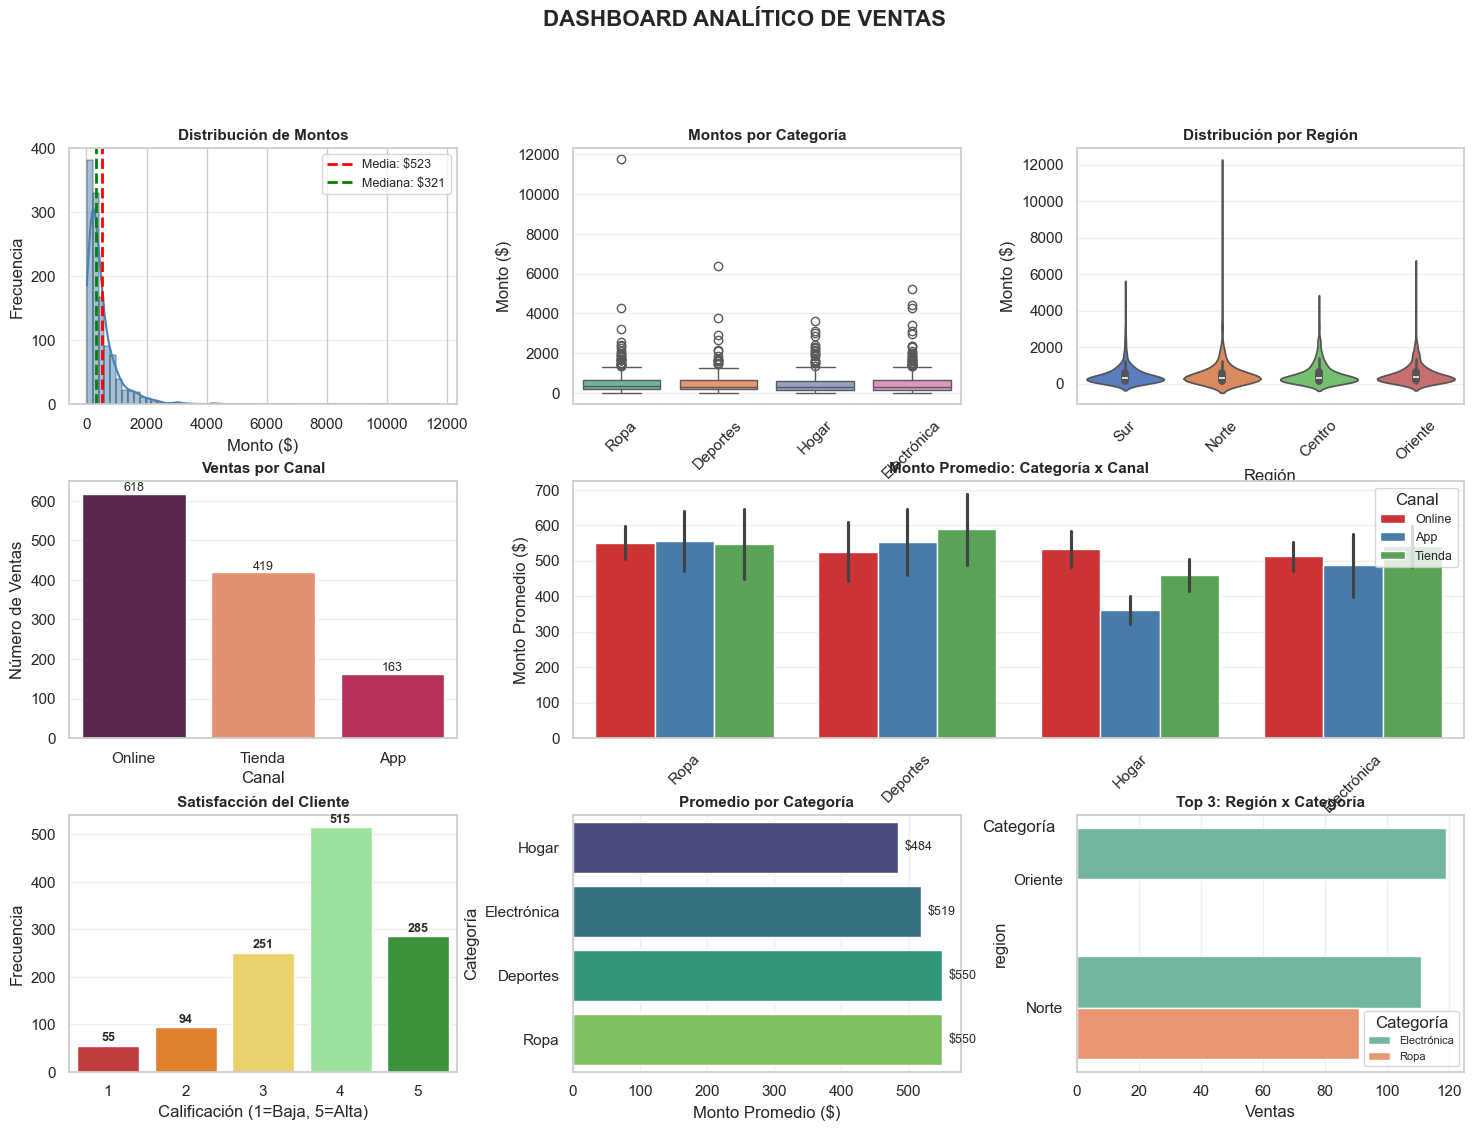

RESUMEN EJECUTIVO
Total transacciones: 1,200
Monto total: $627,646
Ticket promedio: $523.04
Ticket mediano: $321.11
Categoría líder: Electrónica
Canal dominante: Online
Satisfacción promedio: 3.73/5.0
% Satisfechos (4-5): 66.7%


In [12]:
np.random.seed(123)
n = 1200
df_dashboard = pd.DataFrame({
    'monto': np.random.lognormal(5.8, 1.0, n),
    'categoria': np.random.choice(
        ['Electrónica', 'Ropa', 'Hogar', 'Deportes'],
        n, p=[0.32, 0.30, 0.23, 0.15]),
    'region': np.random.choice(['Norte', 'Sur', 'Centro', 'Oriente'], n),
    'canal': np.random.choice(
        ['Online', 'Tienda', 'App'], n, p=[0.52, 0.33, 0.15]),
    'satisfaccion': np.random.choice(
        [1, 2, 3, 4, 5], n, p=[0.05, 0.08, 0.22, 0.40, 0.25])
})

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Histograma de montos
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(data=df_dashboard, x='monto', bins=60, kde=True,
             color='steelblue', edgecolor='black', linewidth=0.3, ax=ax1)
media = df_dashboard['monto'].mean()
mediana = df_dashboard['monto'].median()
ax1.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: ${media:.0f}')
ax1.axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: ${mediana:.0f}')
ax1.set_title('Distribución de Montos', fontsize=11, fontweight='bold')
ax1.set_xlabel('Monto ($)'); ax1.set_ylabel('Frecuencia')
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)

# 2. Boxplot por categoría
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(data=df_dashboard, x='categoria', y='monto',
            hue='categoria', palette='Set2', legend=False, ax=ax2)
ax2.set_title('Montos por Categoría', fontsize=11, fontweight='bold')
ax2.set_xlabel('Categoría'); ax2.set_ylabel('Monto ($)')
ax2.tick_params(axis='x', rotation=45); ax2.grid(axis='y', alpha=0.3)

# 3. Violin por región
ax3 = fig.add_subplot(gs[0, 2])
sns.violinplot(data=df_dashboard, x='region', y='monto',
               hue='region', palette='muted', legend=False, ax=ax3)
ax3.set_title('Distribución por Región', fontsize=11, fontweight='bold')
ax3.set_xlabel('Región'); ax3.set_ylabel('Monto ($)')
ax3.tick_params(axis='x', rotation=45); ax3.grid(axis='y', alpha=0.3)

# 4. Countplot por canal
ax4 = fig.add_subplot(gs[1, 0])
orden_canal = df_dashboard['canal'].value_counts().index
sns.countplot(data=df_dashboard, x='canal', hue='canal',
              palette='rocket', order=orden_canal, legend=False, ax=ax4)
ax4.set_title('Ventas por Canal', fontsize=11, fontweight='bold')
ax4.set_xlabel('Canal'); ax4.set_ylabel('Número de Ventas')
for container in ax4.containers:
    ax4.bar_label(container, fmt='%d', fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# 5. Barplot: categoría x canal
ax5 = fig.add_subplot(gs[1, 1:])
sns.barplot(data=df_dashboard, x='categoria', y='monto',
            hue='canal', palette='Set1', errorbar='se', ax=ax5)
ax5.set_title('Monto Promedio: Categoría x Canal', fontsize=11, fontweight='bold')
ax5.set_xlabel('Categoría'); ax5.set_ylabel('Monto Promedio ($)')
ax5.tick_params(axis='x', rotation=45)
ax5.legend(title='Canal', loc='upper right', fontsize=9); ax5.grid(axis='y', alpha=0.3)

# 6. Distribución de satisfacción
ax6 = fig.add_subplot(gs[2, 0])
sat_counts = df_dashboard['satisfaccion'].value_counts().sort_index()
colores = ['#d62728', '#ff7f0e', '#ffdd57', '#90ee90', '#2ca02c']
sns.barplot(x=sat_counts.index, y=sat_counts.values,
            hue=sat_counts.index, palette=colores, legend=False, ax=ax6)
ax6.set_title('Satisfacción del Cliente', fontsize=11, fontweight='bold')
ax6.set_xlabel('Calificación (1=Baja, 5=Alta)'); ax6.set_ylabel('Frecuencia')
for i, v in enumerate(sat_counts.values):
    ax6.text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=9)
ax6.grid(axis='y', alpha=0.3)

# 7. Promedio por categoría (horizontal, ordenado)
ax7 = fig.add_subplot(gs[2, 1])
cat_avg = df_dashboard.groupby('categoria')['monto'].mean().sort_values()
sns.barplot(y=cat_avg.index, x=cat_avg.values,
            hue=cat_avg.index, palette='viridis', orient='h', legend=False, ax=ax7)
ax7.set_title('Promedio por Categoría', fontsize=11, fontweight='bold')
ax7.set_xlabel('Monto Promedio ($)'); ax7.set_ylabel('Categoría')
for i, v in enumerate(cat_avg.values):
    ax7.text(v + 10, i, f'${v:.0f}', va='center', fontsize=9)
ax7.grid(axis='x', alpha=0.3)

# 8. Top combinaciones región x categoría
ax8 = fig.add_subplot(gs[2, 2])
top_cat_region = df_dashboard.groupby(['region', 'categoria']).size().reset_index(name='count')
top3 = top_cat_region.nlargest(3, 'count')
sns.barplot(data=top3, y='region', x='count', hue='categoria',
            palette='Set2', orient='h', ax=ax8)
ax8.set_title('Top 3: Región x Categoría', fontsize=11, fontweight='bold')
ax8.set_xlabel('Ventas')
ax8.legend(title='Categoría', fontsize=8, loc='lower right'); ax8.grid(axis='x', alpha=0.3)

plt.suptitle('DASHBOARD ANALÍTICO DE VENTAS', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('dashboard_ventas.png', dpi=300, bbox_inches='tight')
plt.show()

# Resumen ejecutivo
print("RESUMEN EJECUTIVO")
print("="*80)
print(f"Total transacciones: {len(df_dashboard):,}")
print(f"Monto total: ${df_dashboard['monto'].sum():,.0f}")
print(f"Ticket promedio: ${df_dashboard['monto'].mean():.2f}")
print(f"Ticket mediano: ${df_dashboard['monto'].median():.2f}")
print(f"Categoría líder: {df_dashboard['categoria'].mode()[0]}")
print(f"Canal dominante: {df_dashboard['canal'].mode()[0]}")
print(f"Satisfacción promedio: {df_dashboard['satisfaccion'].mean():.2f}/5.0")
pct_satisfechos = (df_dashboard['satisfaccion'] >= 4).mean() * 100
print(f"% Satisfechos (4-5): {pct_satisfechos:.1f}%")

## 9. Principios de Diseño Visual

<div style="background-color:#f5ecfb; border-left:5px solid #7b1fa2; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#4a148c; font-size:1.05em;">🎯&nbsp; Buenas Prácticas — Principios de Edward Tufte</p>
<p style="margin:0 0 8px 0;">Edward Tufte es una referencia fundamental en visualización de información. Sus principios principales son:</p>
<p style="margin:0 0 6px 0;"><strong>1. Maximizar el data-ink ratio:</strong> cada elemento visual debe codificar información. Se deben eliminar grillas innecesarias, bordes decorativos, sombras 3D sin función informativa y elementos que ocupan espacio sin aportar datos.</p>
<p style="margin:0 0 6px 0;"><strong>2. Integridad gráfica:</strong> las proporciones visuales deben corresponder a las proporciones numéricas. Las barras comienzan en cero. No se usan perspectivas 3D que distorsionen áreas o alturas. No se truncan ejes para exagerar diferencias.</p>
<p style="margin:0 0 6px 0;"><strong>3. Un mensaje, un gráfico:</strong> cada visualización debe comunicar una sola idea con claridad. El título debe expresar el hallazgo, no simplemente el contenido («Región Oriente presenta latencia 40% superior a la media» es más informativo que «Tiempos de respuesta por región»).</p>
<p style="margin:0;"><strong>4. Facilitar la comprensión:</strong> ejes etiquetados con unidades, colores accesibles ante daltonismo, fuentes legibles y contexto suficiente para interpretar sin necesidad de texto adicional.</p>
</div>

### 9.1 Selección de Paletas de Color

| Tipo | Paletas | Uso recomendado |
|---|---|---|
| **Cualitativa** | Set1, Set2, Paired | Categorías sin orden (productos, regiones) |
| **Secuencial** | Blues, viridis, plasma | Datos con orden (temperatura, edad) |
| **Divergente** | RdBu, coolwarm | Punto medio significativo (cambio %, correlación) |
| **Perceptual** | viridis, cividis | Accesible ante daltonismo (recomendado) |

<div align="center"><em>Tabla 9.1 — Tipos de paletas y sus aplicaciones.</em></div>

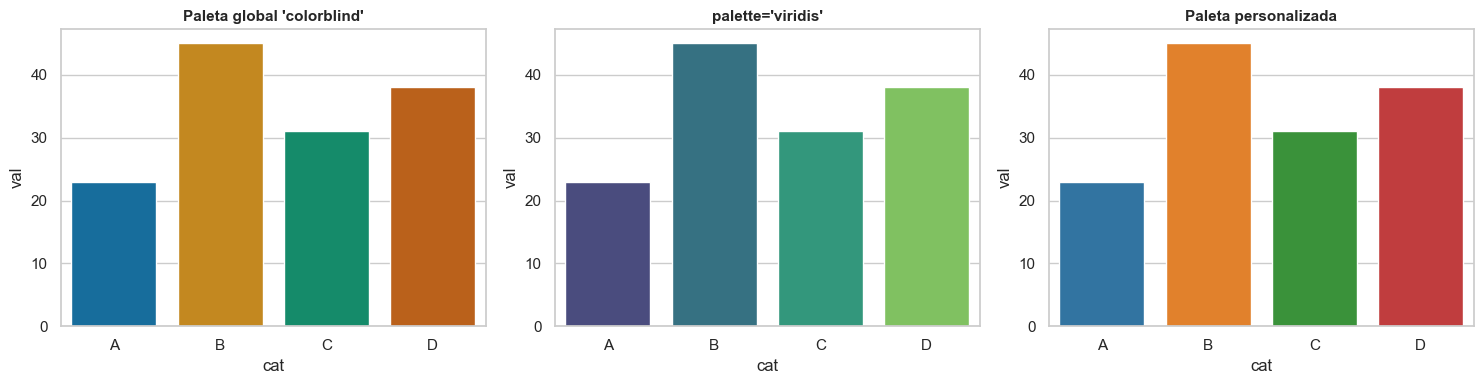

In [13]:
# Demostración de paletas sobre un dataset pequeño
demo = pd.DataFrame({'cat': ['A', 'B', 'C', 'D'], 'val': [23, 45, 31, 38]})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Paleta global accesible
sns.set_palette("colorblind")
sns.barplot(data=demo, x='cat', y='val', hue='cat', legend=False, ax=axes[0])
axes[0].set_title("Paleta global 'colorblind'", fontsize=11, fontweight='bold')

# Paleta específica por gráfico
sns.barplot(data=demo, x='cat', y='val', hue='cat',
            palette='viridis', legend=False, ax=axes[1])
axes[1].set_title("palette='viridis'", fontsize=11, fontweight='bold')

# Paleta personalizada
mis_colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
sns.barplot(data=demo, x='cat', y='val', hue='cat',
            palette=mis_colores, legend=False, ax=axes[2])
axes[2].set_title("Paleta personalizada", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Restaurar tema del notebook
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
sns.set_context("notebook")

### 9.2 Checklist de Calidad

Antes de presentar un gráfico, verificar:

1. ✔ **Título descriptivo** que comunique el hallazgo principal.
2. ✔ **Ejes etiquetados** con unidades ($, %, ms, etc.).
3. ✔ **Leyenda clara** cuando hay múltiples series.
4. ✔ **Escala desde cero** en gráficos de barras.
5. ✔ **Paleta adecuada** al tipo de dato (cualitativa, secuencial, etc.).
6. ✔ **Fuente legible:** mínimo 10pt.
7. ✔ **Proporciones correctas:** sin distorsión de ejes.
8. ✔ **Líneas de referencia** donde aporten contexto (media, objetivo).
9. ✔ **Orden significativo:** por valor, no alfabético.
10. ✔ **Resolución suficiente:** DPI ≥ 300 para reportes impresos.

<div style="background-color:#fdecea; border-left:5px solid #c62828; padding:14px 18px; border-radius:6px; margin:6px 0;">
<p style="margin:0 0 10px 0; font-weight:700; color:#b71c1c; font-size:1.05em;">⚠️&nbsp; Advertencia — Errores Frecuentes en Visualización</p>
<ul style="margin:0;">
<li>Truncar el eje Y en gráficos de barras.</li>
<li>Usar perspectiva 3D sin justificación funcional.</li>
<li>Emplear más de 8 colores distintos en una figura.</li>
<li>Usar gráficos de torta con más de 5 categorías.</li>
<li>Seleccionar un número incorrecto de bins en histogramas.</li>
<li>No reportar ni contextualizar outliers.</li>
<li>Ordenar categorías alfabéticamente en lugar de por valor.</li>
<li>Usar colores no accesibles para personas con daltonismo.</li>
<li>Fuentes demasiado pequeñas para leer en pantalla o impresión.</li>
<li>Sobrecargar una figura con demasiadas variables simultáneas.</li>
</ul>
</div>

## 10. Tabla de Referencia Rápida

| Función | Para | Parámetros clave |
|---|---|---|
| `histplot()` | Histograma | `bins, kde, hue, multiple, stat` |
| `kdeplot()` | Densidad suavizada | `fill, bw_adjust` |
| `boxplot()` | Caja y bigotes | `x, y, hue, showfliers, whis` |
| `violinplot()` | Caja + densidad | `x, y, hue, split` |
| `countplot()` | Conteos categóricos | `x, hue, order` |
| `barplot()` | Barras + estadístico | `x, y, estimator, errorbar` |
| `set_theme()` | Estilo global | `style, palette, font_scale` |
| `set_context()` | Escala de elementos | `'notebook', 'talk', 'poster'` |

<div align="center"><em>Tabla 10.1 — Funciones principales de Seaborn (referencia rápida).</em></div>

### 10.1 Guía de Selección Final

| Objetivo | Gráfico recomendado | Función |
|---|---|---|
| Ver distribución de una variable | Histograma + KDE | `histplot()` |
| Comparar grupos | Boxplot | `boxplot()` |
| Contar frecuencias categóricas | Barras de conteo | `countplot()` |
| Mostrar promedios por grupo | Barras con IC | `barplot()` |
| Detectar outliers | Boxplot | `boxplot()` |
| Verificar normalidad aproximada | Histograma + KDE | `histplot(kde=True)` |
| Presentar rankings | Barras horizontales | `barplot(orient='h')` |
| Comparar forma de distribuciones | Violin | `violinplot()` |

<div align="center"><em>Tabla 10.2 — Criterios de selección por objetivo analítico.</em></div>

### Cierre

<div style="background-color:#ffffff; border:1px solid #d9d9d9; border-left:60px solid #0d2741; border-radius:6px; padding:16px 20px; margin:6px 0;">
<span style="font-size:1.4em;">💡</span>&nbsp; La visualización es tanto ciencia como habilidad comunicativa. La ciencia determina qué gráfico utilizar; la habilidad comunicativa determina cómo presentarlo con claridad e integridad. La diferencia entre un analista junior y uno senior frecuentemente no radica en el dominio técnico, sino en la capacidad de transformar hallazgos en visualizaciones que orienten decisiones. Los histogramas revelan la forma de los datos antes de calcular estadísticos; los boxplots permiten comparaciones robustas y eficientes; las barras comunican magnitudes categóricas con precisión. Seaborn facilita la implementación. La responsabilidad de comunicar con integridad recae siempre en quien construye el gráfico.
</div>

---

## Referencias bibliográficas

- Cairo, A. (2016). *The truthful art: Data, charts, and maps for communication*. New Riders.
- Knaflic, C. N. (2015). *Storytelling with data: A data visualization guide for business professionals*. Wiley.
- Tufte, E. R. (2001). *The visual display of quantitative information* (2nd ed.). Graphics Press.
- Waskom, M. L. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, 6(60), 3021.
- Wilke, C. O. (2019). *Fundamentals of data visualization*. O'Reilly Media.